## Interior point method

In [28]:
import numpy as np
import pandas as pd
import copy as copy
import scipy
import scipy.io
import time
import os
from scipy.linalg import solve, LinAlgWarning
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random

from matplotlib.animation import FuncAnimation, PillowWriter
import openpyxl
import xlsxwriter

import importlib
from IPM_functions import (
    loadProblem,
    create_result_dataframes,
    update_result_dataframes,
    highlight_greaterthan,
    paso_intpoint,
    solve_catch_error,
    update_active_set_mask,
    active_set_diagnostics,
    progress_summary_df_clean,
    build_reduced_system,
    load_lp_problem
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Método de puntos interiores (sin heurística)

In [34]:
# Choose a file
#mat_file = 'lp_kb2.mat'     # b = 0
#mat_file = 'lp_afiro.mat'   # bmax = 500, and no mu tends to zero  and no condition problem
#mat_file = 'lp_blend.mat'    # bmax = 26.32, and no mu tends to zero.
mat_file = 'lp_fit1d.mat'   # b = 0
#mat_file = 'lp_fit1p.mat'   # bmax = 216, and no mu tends to zero, condition 10^12
#mat_file = 'lp_grow15.mat'  # b = 0, condition 10^6
#mat_file = 'lp_grow22.mat'  # b = 0, condition 1.4e7
#mat_file = 'lp_grow7.mat'   # b = 0, condition 1.2e7

# Load problem
Q, c, A, b, F, d, H = load_lp_problem(mat_file)
AT = A.T
FT = F.T

k = 0
n = Q.shape[0]
m = A.shape[0]
p = F.shape[0]

# Initial values
x = np.ones(n)
lamda = np.zeros(m)
mu = np.ones(p)
#z = np.ones(p)
z = F @ x - d + (0.5)*np.ones(p)

problem_info = {
    "problem_name": mat_file,
    "norm_inf_b": np.linalg.norm(b, np.inf),
    "dim_b": len(b),
    "num_zeros_b": np.sum(b==0),
    "dim_x": n,
    "dim_eq": m,
    "dim_ineq": p
}

tol = 1e-6
kmax = 100

sigma = 0.5
M_c = np.dot(mu, z) / p
tau = sigma * M_c

alphas = []

obj_function_value = 0.5 * x @ Q @ x + c @ x
max_complementarity_value = np.max(mu * z)

#Define and initialise the dataframes that will be used to record the results on every iteration for mu, z, tau, the maximum complementarity value: max(mu_i * z_i), and the objective value
mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history = create_result_dataframes(p)
mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history = update_result_dataframes(k, mu, z, tau, obj_function_value, max_complementarity_value, p, mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history)

while k < kmax:

    # Define and update diagonal matri¡ces D_z and D_mu inside the loop
    D_z = np.diag(z)
    D_mu = np.diag(mu)

    r_x = Q @ x - AT @ lamda - FT @ mu + c
    r_lamda = - A @ x + b
    r_mu = -F @ x + d + z
    r_z = np.multiply(mu, z)

    F_x = np.concatenate((r_x, r_lamda, r_mu, r_z), 0)
    KKT_norm = np.linalg.norm(F_x, np.inf)

    if KKT_norm < tol:
        print("CNPO norm is below the tolerance, stopping iterations.")
        cnpo_norm = KKT_norm
        primal_residual_norm            = np.linalg.norm(r_lamda, np.inf)
        inequality_residual_norm        = np.linalg.norm(r_mu, np.inf)
        max_complementarity             = np.max(r_z)
        barrier_parameter               = tau
        cond_new_K                      = 1/np.linalg.cond(nuevo_sistema,1)
        objective_value                 =  0.5 * x @ Q @ x + c @ x
        break

    red_mu = []
    
    # Build the reduced system we will use for calculating
    D = np.diag(mu / z)
    G = Q+FT@D@F
    w = F @ x - d - (tau / mu)
        
    dg = Q @ x - AT @ lamda - FT@mu + c + FT@D@w
    
    # Define K as a block matrix
    m = A.shape[0]
    K = np.block([
        [G, -AT],
        [-A, np.zeros((m, m))]
    ])
    
    # Calculate the condition number of G
    condG = np.linalg.cond(G,1)
    
    # Define lado derecho of the system of equations (ld)
    ld = -np.concatenate([dg, -A @ x + b])
    #KKT_norm = np.linalg.norm(ld, np.inf)

    # Build the PROPER REDUCED system we will use for calculating
    fila1 = np.hstack((Q, -AT, -FT @ D_mu))
    fila2 = np.hstack((-A, np.zeros((m, m + p))))
    fila3 = np.hstack((-D_mu @ F, np.zeros((p, m)), -np.diag(mu * z)))

    nuevo_sistema = np.vstack((fila1, fila2, fila3))

    L = np.concatenate((
        r_x ,   # dual residual
        r_lamda,                          # primal residual
        D_mu @ (d - F @ x) + tau               # complementarity row
    ))
    
    print("condK:", 1/np.linalg.cond(K,1))
    print("reduced system condition number:", 1/np.linalg.cond(nuevo_sistema,1))

    # Solve the linear system and catch any ill-conditioning warnings from SciPy
    delta_vector1 = solve_catch_error(nuevo_sistema,-L,k) # Reduced system to n+m+p dimensions

    delta_x     = delta_vector1[:n] # should be the same ?
    delta_lamda = delta_vector1[n:n + m] # should be the same ?
    Ddelta_mu    = delta_vector1[n + m:]
    
    delta_mu = D_mu @ Ddelta_mu  # Divide each element of delta_mu1 by the corresponding diagonal element of D_mu

    # Reconstruct Δz from the 3rd KKT row (primal feasibility)
    # δz = F δx + (Fx - d - z)  == F @ delta_x - r_mu  (since r_mu = -F@x + d + z)
    delta_z = F @ delta_x - r_mu
    
    ### Step size reduction
    alpha_mu = paso_intpoint(mu, delta_mu)
    alpha_z  = paso_intpoint(z, delta_z)
    print("alpha_mu:", alpha_mu)
    print("alpha_z:", alpha_z)
    alpha    = min(alpha_mu, alpha_z)
    #alpha    = 0.995 * min(alpha_mu, alpha_z) # From Javi's thesis
    print("alpha= " , alpha)
    alphas.append(alpha)

    if alpha_mu >= 0.9 and alpha_z >= 0.9:
        sigma = max(10**-4,sigma/10)
    print(sigma)
    
    # Percentage changes before we udpate mu and z
    mu_percentage_change = delta_mu/mu
    z_percentage_change  = delta_z/z
    
    # Update variables
    x += alpha * delta_x
    mu += alpha * delta_mu
    lamda += alpha * delta_lamda
    z += alpha * delta_z
    
    # Update tau and residuals
    tau = sigma * np.dot(mu, z) / (p)
    k += 1

    # Recalculate the objective function value and maximum complementarity value for this iteration
    obj_function_value = 0.5 * x @ Q @ x + c @ x
    max_complementarity_value = np.max(mu * z)

    #Update the dataframes that record the values for each iteration
    mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history = update_result_dataframes(k, mu, z, tau,
                             obj_function_value, max_complementarity_value, p,
                             mu_df, z_df, tau_df,
                             obj_function_df, max_complementarity_df,
                             active_set_history)

    # Review if mu and z have been meeting the criteria we want (for the last 3 iterations) in order to
    # eliminate them when we start our experiment.
    active_set_history = update_active_set_mask(mu, z, Q, k, tau, active_set_history, mu_df, mu_percentage_change, z_percentage_change)

    # We save these values again because we're saving them separately so we can update the original variables once we run the heuristic/experiment
    # This allows us to save relevant values of the regular IPM method.

    #------ This sections is used for reference, but not used for any calculations -------#
    #------ This checks how many of if all components of the complementarity are below a set tolerance (Courtesy of Andreas), and if indices are a subset of the previous indices

    # Create a boolean mask that checks if all components of the complementarity are below a set tolerance
    mask = mu*z <= 1e-5
    
    #print('cuantos chicos mu*z = %g, vector\n' % (sum(mask)), (mu*z)[mask])
    
    #If all values of mu*z are below the tolerance, we check if the indices that fulfil this are a subset of the previous indices that fulfilled this
    if all(mask): #Return True only if EVERY entry in mask is True
        # Once the mu and z have gotten sufficiently small,

        #neg_mu_mask = (-0.52 < mu_percentage_change) & (mu_percentage_change < -0.48)
        #const_z_mask = (-0.01 < z_percentage_change) & (z_percentage_change < 0.01)
        grow_z_mask = (z_percentage_change > -0.03) #& (z_percentage_change < 0.01)
        neg_mu = np.arange( len(mask) )[grow_z_mask]
        
        active_set_history = update_active_set_mask(mu, z, Q, k, tau, active_set_history, mu_df, mu_percentage_change, z_percentage_change)
        
        #print('mus chicos: vector\n', mu[neg_mu])
        if set(red_mu).issubset( neg_mu ):
            print ('IS subset: GOOD')
        else:
            print ('FAILS subset condition: BAD')
            
        #print('mus chicos: vector\n', neg_mu)
        #print('  change in percentages for mu \n', mu_percentage_change[neg_mu] )
        #print('zs tending to positive contants\n', z[neg_mu] )
        #print('  Largest and smallest change for percentages in entries of z  \n', min(z_percentage_change[neg_mu]), max(z_percentage_change[neg_mu] ))
        red_mu = neg_mu.copy()

print("Número de iteraciones hasta el criterio de paro:",k)

problem_results_before_heuristic = {
    "KKT residual (‖r‖∞)": cnpo_norm,
    "Primal residual (‖r_p‖∞)": primal_residual_norm,
    "Inequality residual (‖r_d‖∞)": inequality_residual_norm,
    "Complementarity gap (max μᵢ zᵢ)": max_complementarity,
    "Barrier parameter (τ)": barrier_parameter,
    "Condition number κ(K)": cond_new_K,
    "Objective value f(x)": objective_value
}

summary_before = progress_summary_df_clean(problem_results_before_heuristic)

display(summary_before)

print("cond_old_K:", np.linalg.cond(K,1))
print("reduced system condition number:", 1/np.linalg.cond(nuevo_sistema,1))

Loading problem from: lp_fit1d.mat
Norma infinita de b:  0.0
Problem loaded. n=1049, m=24, p=1049
Number of zeros in b: 24 (100.00%)
condK: 5.465190393940983e-07
reduced system condition number: 3.33583568398285e-07
alpha_mu: 0.014762081778078652
alpha_z: 0.0019426260615199912
alpha=  0.0019426260615199912
0.5
condK: 5.462645400224317e-07
reduced system condition number: 3.2781202243092473e-07
alpha_mu: 0.01729765226769398
alpha_z: 0.0015766659345749791
alpha=  0.0015766659345749791
0.5
condK: 5.460838125522941e-07
reduced system condition number: 3.236433503332957e-07
alpha_mu: 0.019435221097990604
alpha_z: 0.0038774680567647437
alpha=  0.0038774680567647437
0.5
condK: 5.456257223397805e-07
reduced system condition number: 3.1466690779456556e-07
alpha_mu: 0.02326158314128581
alpha_z: 0.006320180631625184
alpha=  0.006320180631625184
0.5
condK: 5.44673700849886e-07
reduced system condition number: 3.058306657061046e-07
alpha_mu: 0.02286218697601899
alpha_z: 0.010853241187796849
alpha= 

,Metric,Before
0,KKT residual (‖r‖∞),2.490011e-07
1,Primal residual (‖r_p‖∞),3.376533e-10
2,Inequality residual (‖r_d‖∞),0.000000e+00
3,Complementarity gap (max μᵢ zᵢ),2.490011e-07
4,Barrier parameter (τ),2.490574e-14
5,Condition number κ(K),3.285500e-18
6,Objective value f(x),-9.025019e+04


cond_old_K: 3.2749206284374606e+19
reduced system condition number: 3.2854998119378355e-18


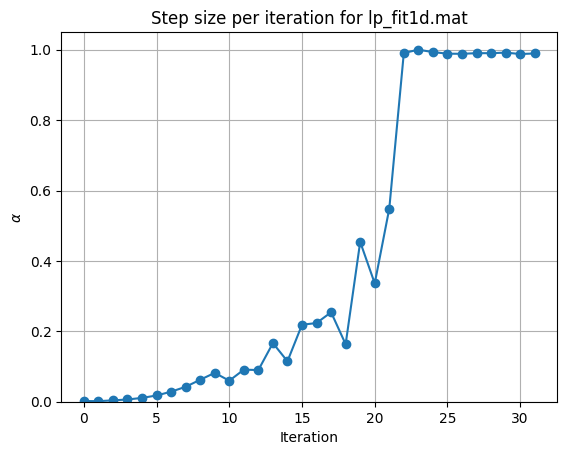

In [35]:
plt.plot(alphas, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$\alpha$')
plt.title(f"Step size per iteration for {mat_file}")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [19]:
# Choose a file
mat_file = 'lp_kb2.mat'     # b = 0
#mat_file = 'lp_afiro.mat'   # bmax = 500, and no mu tends to zero  and no condition problem
#mat_file = 'lp_blend.mat'    # bmax = 26.32, and no mu tends to zero.
#mat_file = 'lp_fit1d.mat'   # b = 0
#mat_file = 'lp_fit1p.mat'   # bmax = 216, and no mu tends to zero, condition 10^12
#mat_file = 'lp_grow15.mat'  # b = 0, condition 10^6
#mat_file = 'lp_grow22.mat'  # b = 0, condition 1.4e7
#mat_file = 'lp_grow7.mat'   # b = 0, condition 1.2e7

# Load problem
Q, c, A, b, F, d, H = load_lp_problem(mat_file)
AT = A.T
FT = F.T

k = 0
n = Q.shape[0]
m = A.shape[0]
p = F.shape[0]

# Initial values
x = np.ones(n)
lamda = np.zeros(m)
mu = np.ones(p)
z = np.ones(p)
#z = F @ x - d + (0.5)*np.ones(p)

problem_info = {
    "problem_name": mat_file,
    "norm_inf_b": np.linalg.norm(b, np.inf),
    "dim_b": len(b),
    "num_zeros_b": np.sum(b==0),
    "dim_x": n,
    "dim_eq": m,
    "dim_ineq": p
}

tol = 1e-6
kmax = 100

sigma = 0.5 # Valor fijo
tau = sigma * np.dot(mu, z) / p

obj_function_value = 0.5 * x @ Q @ x + c @ x
max_complementarity_value = np.max(mu * z)

#Define and initialise the dataframes that will be used to record the results on every iteration for mu, z, tau, the maximum complementarity value: max(mu_i * z_i), and the objective value
mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history = create_result_dataframes(p)
mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history = update_result_dataframes(k, mu, z, tau, obj_function_value, max_complementarity_value, p, mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history)

r_x = Q @ x + AT @ lamda - FT @ mu + c
r_lamda = A @ x - b
r_mu = -F @ x + d + z
r_z = np.multiply(mu, z) 

# F_x is the right-hand side of the complete system with the residuals(but we use the reduces system to solve)
F_x = np.concatenate((r_x, r_lamda, r_mu, r_z), 0)
KKT_norm = np.linalg.norm(F_x,np.inf) # this is the CNPO (Condiciones necesarias de primer orden) without the perturbation

red_mu = []

while KKT_norm > tol and k < kmax:
    # Update diagonal matri¡ces D_z and D_mu inside the loop
    D_z = np.diag(z)
    D_mu = np.diag(mu)

    ### KKT Matrix (we don't actually use this for calculations as we're using the reduced system).
    # Initial residuals
    row1 = np.hstack((Q, AT, -FT, np.zeros((n, p))))
    row2 = np.hstack((A, np.zeros((m, m + p + p))))
    row3 = np.hstack((-F, np.zeros((p, m + p)), np.identity(p)))
    row4 = np.hstack((np.zeros((p, n + m)), D_z, D_mu))

    M = np.vstack((row1, row2, row3, row4))
    
    # Build the reduced system we will use for calculating
    D = np.diag(mu / z)
    G = Q+FT@D@F
    w = F @ x - d - (tau / mu)
        
    dg = Q @ x + AT @ lamda - FT@mu + c + FT@D@w
    
    # Define K as a block matrix
    m = A.shape[0]
    K = np.block([
        [G, AT],
        [A, np.zeros((m, m))]
    ])
    
    # Calculate the condition number of G
    condG = np.linalg.cond(G,1)
    
    # Define lado derecho of the system of equations (ld)
    ld = -np.concatenate([dg, A @ x - b])
    #KKT_norm = np.linalg.norm(ld, np.inf)
    
    # Solve the linear system and catch any ill-conditioning warnings from SciPy
    delta_vector = solve_catch_error(K,ld,k) # Reduced system
    
    # Update the sections of the delta_vector
    delta_x     = delta_vector[0:n]
    delta_lamda = delta_vector[n:n + m]
    delta_mu    = - D @ (F @ delta_x + w)
    delta_z     = - ( (1 / mu) * (z * delta_mu - tau) + z )
    
    ### Step size reduction
    alpha_mu = paso_intpoint(mu, delta_mu)
    alpha_z  = paso_intpoint(z, delta_z)
    alpha    = min(alpha_mu, alpha_z)
    #alpha    = 0.995 * min(alpha_mu, alpha_z) # From Javi's thesis
    #print("alpha= " , alpha)
    
    # Percentage changes before we udpate mu and z
    mu_percentage_change = delta_mu/mu
    z_percentage_change  = delta_z/z
    
    # Update variables
    x += alpha * delta_x
    mu += alpha * delta_mu
    lamda += alpha * delta_lamda
    z += alpha * delta_z
    
    # Update tau and residuals
    tau = sigma * np.dot(mu, z) / (p)
    k += 1

    # Recalculate the objective function value and maximum complementarity value for this iteration
    obj_function_value = 0.5 * x @ Q @ x + c @ x
    max_complementarity_value = np.max(mu * z)

    #Update the dataframes that record the values for each iteration
    mu_df, z_df, tau_df, obj_function_df, max_complementarity_df, active_set_history = update_result_dataframes(k, mu, z, tau,
                             obj_function_value, max_complementarity_value, p,
                             mu_df, z_df, tau_df,
                             obj_function_df, max_complementarity_df,
                             active_set_history)

    # Review if mu and z have been meeting the criteria we want (for the last 3 iterations) in order to
    # eliminate them when we start our experiment.
    active_set_history = update_active_set_mask(mu, z, Q, k, tau, active_set_history, mu_df, mu_percentage_change, z_percentage_change)

    # Recalculate residuals
    r_x = Q @ x + AT @ lamda - FT @ mu + c
    r_lamda = A @ x - b
    r_mu = -F @ x + d + z
    r_z = np.multiply(mu, z)  # Element-wise product
    
    F_x = np.concatenate((r_x, r_lamda, r_mu, r_z), 0)
    KKT_norm = np.linalg.norm(F_x,np.inf)

    # We save these values again because we're saving them separately so we can update the original variables once we run the heuristic/experiment
    # This allows us to save relevant values of the regular IPM method.
    
    cnpo_norm = KKT_norm
    primal_residual_norm   = np.linalg.norm(r_lamda, np.inf)
    inequality_residual_norm   = np.linalg.norm(r_mu, np.inf)
    max_complementarity   = np.max(r_z)
    barrier_parameter   = tau
    cond_G  = condG
    objective_value   =  0.5 * x @ Q @ x + c @ x

    #print("\niter=", k, "\t", "||cnpo||=", KKT_norm)
    #print("Condition number of G:", np.linalg.cond(G,1))
    #print("rcond(G)", (1/np.linalg.cond(G,1)))
    #print("tau =",tau)
    #print(z)
    #print(mu)

    #------ This sections is used for reference, but not used for any calculations -------#

    #------ This checks how many of if all components of the complementarity are below a set tolerance (Courtesy of Andreas), and if indices are a subset of the previous indices

    # Create a boolean mask that checks if all components of the complementarity are below a set tolerance
    mask = mu*z <= 1e-5
    
    #print('cuantos chicos mu*z = %g, vector\n' % (sum(mask)), (mu*z)[mask])
    
    #If all values of mu*z are below the tolerance, we check if the indices that fulfil this are a subset of the previous indices that fulfilled this
    if all(mask): #Return True only if EVERY entry in mask is True
        # Once the mu and z have gotten sufficiently small,

        #neg_mu_mask = (-0.52 < mu_percentage_change) & (mu_percentage_change < -0.48)
        #const_z_mask = (-0.01 < z_percentage_change) & (z_percentage_change < 0.01)
        grow_z_mask = (z_percentage_change > -0.03) #& (z_percentage_change < 0.01)
        neg_mu = np.arange( len(mask) )[grow_z_mask]
        
        active_set_history = update_active_set_mask(mu, z, Q, k, tau, active_set_history, mu_df, mu_percentage_change, z_percentage_change)
        
        #print('mus chicos: vector\n', mu[neg_mu])
        if set(red_mu).issubset( neg_mu ):
            print ('IS subset: GOOD')
        else:
            print ('FAILS subset condition: BAD')
            
        #print('mus chicos: vector\n', neg_mu)
        #print('  change in percentages for mu \n', mu_percentage_change[neg_mu] )
        #print('zs tending to positive contants\n', z[neg_mu] )
        #print('  Largest and smallest change for percentages in entries of z  \n', min(z_percentage_change[neg_mu]), max(z_percentage_change[neg_mu] ))
        red_mu = neg_mu.copy()

print("Número de iteraciones hasta el criterio de paro:",k)

problem_results_before_heuristic = {
    "KKT residual (‖r‖∞)": cnpo_norm,
    "Primal residual (‖r_p‖∞)": primal_residual_norm,
    "Inequality residual (‖r_d‖∞)": inequality_residual_norm,
    "Complementarity gap (max μᵢ zᵢ)": max_complementarity,
    "Barrier parameter (τ)": barrier_parameter,
    "Condition number κ(G)": cond_G,
    "Objective value f(x)": objective_value
}

summary_before = progress_summary_df_clean(problem_results_before_heuristic)

display(summary_before)

print("RcondG:", 1/condG)

Loading problem from: lp_kb2.mat
Norma infinita de b:  0.0
Problem loaded. n=68, m=43, p=68
Number of zeros in b: 43 (100.00%)
IS subset: GOOD
[Iteration 22] Index 44 stopped meeting at least one criteria to be considered as zero:
   - z decreased too fast (Δz/z = -4.40%, threshold = -3%)
FAILS subset condition: BAD
IS subset: GOOD
IS subset: GOOD
IS subset: GOOD
Número de iteraciones hasta el criterio de paro: 25


,Metric,Before
0,KKT residual (‖r‖∞),5.687593e-07
1,Primal residual (‖r_p‖∞),4.163336e-17
2,Inequality residual (‖r_d‖∞),6.938894e-18
3,Complementarity gap (max μᵢ zᵢ),5.687593e-07
4,Barrier parameter (τ),2.417428e-07
5,Condition number κ(G),1.600277e+08
6,Objective value f(x),-2.081737e-02


RcondG: 6.248917287565726e-09
